#Import Libraries

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
os.makedirs("/images" , exist_ok = True)
import os
csv_files = [
    f for f in os.listdir('/content')
    if f.endswith('.csv')
]
print(csv_files)

['netflix_titles.csv']


#Load Dataset

In [2]:
df = pd.read_csv('netflix_titles.csv')

In [9]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [10]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


#Checking Missing Values

In [11]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


#find duplicate records

In [13]:
df.duplicated().sum()

np.int64(0)

#Data Cleaning(Fill missing values & remove duplicate values)

In [14]:
df["director"] = df["director"].fillna("Unknown")

df["cast"] = df["cast"].fillna("Not Available")

df["country"] = df["country"].fillna("Unknown")

df["date_added"] = df["date_added"].fillna(
    df["date_added"].mode()[0]
)

df["rating"] = df["rating"].fillna(
    df["rating"].mode()[0]
)

df["duration"] = df["duration"].fillna(
    df["duration"].mode()[0]
)

df = df.drop_duplicates()

print("Remaining Missing Values:")
print(df.isnull().sum())

Remaining Missing Values:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


#save cleaned dataset

In [48]:
df.to_csv('cleaned_dataset.csv', index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


#summary statistics

In [19]:
df.describe(include = 'all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,8807,8807,8807,8807,8807.000000,8807,8807,8807,8807
unique,8807,2,8807,4529,7693,749,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Unknown,Not Available,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,2634,825,2818,119,NaN,3211,1796,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


#visualization 1

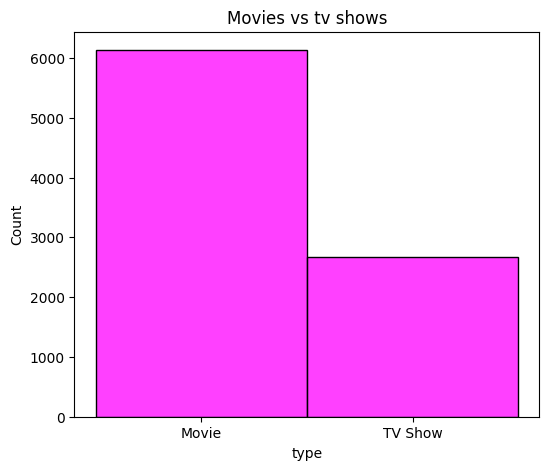

In [66]:
plt.figure(figsize=(6,5))
sns.histplot(data=df, x="type", color= "magenta")
plt.title("Movies vs tv shows")
plt.savefig("histplot.png", bbox_inches='tight')
plt.show()

#visualisation 2

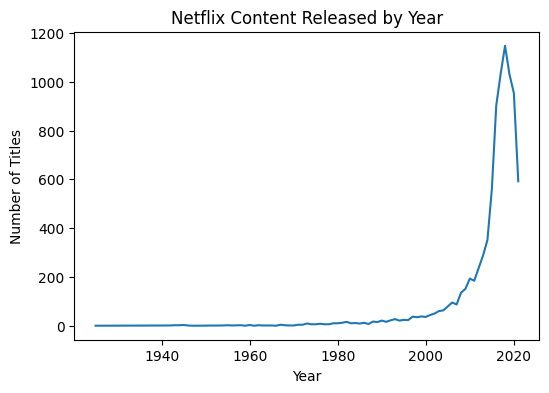

In [59]:
plt.figure(figsize=(6,4))
df["release_year"].value_counts().sort_index().plot()
plt.title("Netflix Content Released by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.savefig("release_trend.png", bbox_inches='tight')
plt.show()

#visualisation 3

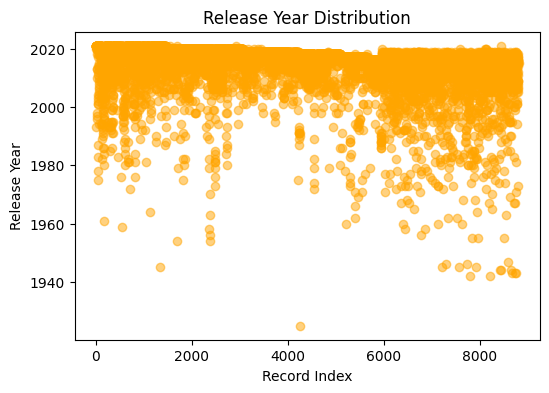

In [57]:
plt.figure(figsize=(6,4))
plt.scatter(
    range(len(df)),
    df['release_year'],
    alpha=0.5, color = 'orange'
)
plt.title("Release Year Distribution")
plt.xlabel("Record Index")
plt.ylabel("Release Year")
plt.savefig("scatterplot.png", bbox_inches='tight')
plt.show()